# Clinical Features MLP — Component 2 Arm 1

Trains a small MLP on structured patient data only (no image, no text).
Uses the same patients and splits as Component 1 for a valid comparison.

**Features**: age, sex, AP/PA view, race, ethnicity, insurance type, BMI  
**Labels**: same 14-label weighted BCE as Component 1 baseline  
**Purpose**: establish how much demographics alone can predict each pathology,
and identify which features drive predictions via SHAP (bias signal).

**Runs on MacBook** — no images, tiny model, finishes in minutes even on full set.

**Outputs**
- `splits/*_clin.csv` — enriched splits reused by notebooks 08 and 09
- `weights/clinical_encoder.pkl` — fitted feature scaler, reused by 08 and 09
- `checkpoints/clinical_mlp_best.pt`
- `checkpoints/clinical_mlp_auc.csv`
- `maps/shap/clinical_shap.npy` — SHAP values [14 classes × n_val × 14 features]
- `maps/shap/clinical_summary.png`

In [1]:
# ── Cell 1 — Environment ──────────────────────────────────────────────────────
import sys, os

try:
    import google.colab
    IS_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive')
    if not os.path.exists('/content/dizertatie_project'):
        !git clone https://github.com/daviDpaD18/diz.git /content/diz
        os.symlink('/content/diz/dizertatie_project', '/content/dizertatie_project')
    sys.path.insert(0, '/content/dizertatie_project')
except ImportError:
    IS_COLAB = False
    sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))

print('Colab:', IS_COLAB)

Colab: False


In [2]:
# ── Cell 2 — Imports ──────────────────────────────────────────────────────────
import json, pickle, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

from src.config import SPLITS_DIR, WEIGHTS_DIR, CKPT_DIR
from src.dataset import LABEL_COLS, remap_uncertain

CKPT_DIR.mkdir(parents=True, exist_ok=True)
MAPS_DIR = (CKPT_DIR.parent / 'maps') if IS_COLAB \
           else Path('..').resolve() / 'maps'
(MAPS_DIR / 'shap').mkdir(parents=True, exist_ok=True)

DEVICE = (
    torch.device('cuda') if torch.cuda.is_available() else
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cpu')
)
print('Device:', DEVICE)

Device: mps


In [3]:
# ── Cell 3 — Create enriched splits ───────────────────────────────────────────
#
# Joins the Component 1 splits with df_chexpert_plus_240401.csv on path_to_image.
# Adds race, ethnicity, insurance_type, recent_bmi, section_impression,
# section_findings to every row. Skips if enriched files already exist.
#
# Coverage (verified):
#   race / insurance / BMI : 202/202 val, 4999/5000 train
#   section_impression     : 202/202 val  ← primary text for notebooks 08/09
#   section_findings       :  63/202 val  ← used when available, else empty
#
# MacBook: runs from the local df_chexpert_plus_240401.csv
# Colab  : enriched CSVs must already be on Drive (copy from local splits/ folder)

COLS_TO_ADD = [
    'race', 'ethnicity', 'interpreter_needed', 'insurance_type', 'recent_bmi',
    'section_findings', 'section_impression',
]

# Locate df_chexpert_plus — local project root or Drive
if IS_COLAB:
    full_csv = Path('/content/drive/MyDrive/dizertatie') / 'df_chexpert_plus_240401.csv'
else:
    full_csv = Path('..').resolve() / 'df_chexpert_plus_240401.csv'

def enrich_split(src_csv, dst_csv, full_df):
    if dst_csv.exists():
        print(f'  {dst_csv.name} already exists — skipping.')
        return
    df     = pd.read_csv(src_csv)
    joined = df.merge(
        full_df[['path_to_image'] + COLS_TO_ADD],
        left_on='Path', right_on='path_to_image', how='left'
    ).drop(columns='path_to_image')
    joined.to_csv(dst_csv, index=False)
    n = joined['race'].notna().sum()
    print(f'  {dst_csv.name}: {len(joined)} rows, {n}/{len(joined)} clinical matched')

if full_csv.exists():
    print('Loading df_chexpert_plus for enrichment (one-time, ~30s)...')
    full_df = pd.read_csv(full_csv, low_memory=False,
                          usecols=['path_to_image'] + COLS_TO_ADD)
    for src, dst in [
        ('train_dev5k.csv',  'train_dev5k_clin.csv'),
        ('valid_frontal.csv','valid_frontal_clin.csv'),
    ]:
        enrich_split(SPLITS_DIR / src, SPLITS_DIR / dst, full_df)
    if (SPLITS_DIR / 'train_full.csv').exists():
        enrich_split(SPLITS_DIR / 'train_full.csv',
                     SPLITS_DIR / 'train_full_clin.csv', full_df)
    del full_df   # free memory
    print('Enrichment done.')
    if not IS_COLAB:
        print('Upload splits/*_clin.csv to Drive before running on Colab.')
else:
    print('df_chexpert_plus not found — checking for pre-enriched CSVs...')
    missing = [f for f in ['train_dev5k_clin.csv', 'valid_frontal_clin.csv']
               if not (SPLITS_DIR / f).exists()]
    if missing:
        raise FileNotFoundError(
            f'Missing: {missing}. Run enrichment locally first, then upload to Drive.')
    print('Pre-enriched CSVs found.')

Loading df_chexpert_plus for enrichment (one-time, ~30s)...
  train_dev5k_clin.csv already exists — skipping.
  valid_frontal_clin.csv already exists — skipping.
  train_full_clin.csv already exists — skipping.
Enrichment done.
Upload splits/*_clin.csv to Drive before running on Colab.


In [4]:
# ── Cell 4 — Constants + class weights ───────────────────────────────────────
#
# TRAIN_CSV: use train_full_clin.csv on both MacBook and Colab.
# The clinical MLP has no images — the full 147k set trains in ~5 min on CPU.
# Switch to train_dev5k_clin.csv only if you want a quick smoke test.

TRAIN_CSV    = SPLITS_DIR / 'train_full_clin.csv'     # full set, works on MacBook too
VALID_CSV    = SPLITS_DIR / 'valid_frontal_clin.csv'
RELIABLE_MIN = 5
RARE_LABELS  = ['Pneumonia', 'Fracture', 'Lung Lesion', 'Pleural Other']

TRAIN_EPOCHS = 100
BATCH_SIZE   = 256
LR           = 1e-3
WEIGHT_DECAY = 1e-3

with open(WEIGHTS_DIR / 'class_weights.json') as f:
    cw = json.load(f)
CLASS_WEIGHTS = torch.tensor([cw[l] for l in LABEL_COLS],
                              dtype=torch.float32).to(DEVICE)

def weighted_bce(logits, labels):
    return (F.binary_cross_entropy_with_logits(
        logits, labels, reduction='none') * CLASS_WEIGHTS).mean()

In [5]:
# ── Cell 5 — Feature encoding ─────────────────────────────────────────────────
#
# 14 features total:
#   age (1) | sex_male, sex_unknown (2) | ap_pa (1) |
#   race_black, race_asian, race_other (3) | hispanic (1) |
#   ins_medicare, ins_medicaid, ins_unknown, ins_other (4) |
#   bmi, bmi_missing (2)
#
# White = race reference, Private Insurance = insurance reference.
# Fitted on training set only; stats saved to weights/ for reuse in 08/09.

FEATURE_NAMES = [
    'age',
    'sex_male', 'sex_unknown',
    'ap_pa',
    'race_black', 'race_asian', 'race_other',
    'hispanic',
    'ins_medicare', 'ins_medicaid', 'ins_unknown', 'ins_other',
    'bmi', 'bmi_missing',
]
N_FEATURES = len(FEATURE_NAMES)


def encode_features(df, stats=None):
    """Returns (float32 matrix [N, 14], stats dict).
    Pass stats=None for the training set (fits scalers);
    pass the returned stats dict for val/test (reuses fitted values)."""
    feats = pd.DataFrame(index=df.index)
    fit   = stats is None
    if fit:
        stats = {}

    # Age
    age = df['Age'].fillna(df['Age'].median() if fit else stats['age_median'])
    if fit:
        stats['age_median'] = float(df['Age'].median())
        stats['age_mean']   = float(age.mean())
        stats['age_std']    = float(age.std())
    feats['age'] = (age - stats['age_mean']) / (stats['age_std'] + 1e-8)

    # Sex
    feats['sex_male']    = (df['Sex'] == 'Male').astype(float)
    feats['sex_unknown'] = (~df['Sex'].isin(['Male', 'Female'])).astype(float)

    # AP/PA (frontal only — should only be AP or PA)
    feats['ap_pa'] = (df['AP/PA'] == 'AP').astype(float)

    # Race  (White = reference → all zeros)
    race = df.get('race', pd.Series('Unknown', index=df.index)).fillna('Unknown')
    feats['race_black'] = (race == 'Black').astype(float)
    feats['race_asian'] = (race == 'Asian').astype(float)
    feats['race_other'] = race.isin(
        ['Other', 'Unknown', 'Pacific Islander', 'Native American']).astype(float)

    # Ethnicity
    ethnicity = df.get('ethnicity', pd.Series('', index=df.index)).fillna('')
    feats['hispanic'] = ethnicity.str.contains('Hispanic/Latino',
                                                na=False).astype(float)

    # Insurance  (Private Insurance = reference → all zeros)
    ins = df.get('insurance_type', pd.Series('Unknown', index=df.index)).fillna('Unknown')
    feats['ins_medicare'] = (ins == 'Medicare').astype(float)
    feats['ins_medicaid'] = (ins == 'Medicaid').astype(float)
    feats['ins_unknown']  = (ins == 'Unknown').astype(float)
    feats['ins_other']    = (ins == 'Other').astype(float)

    # BMI
    bmi_raw = df.get('recent_bmi', pd.Series(np.nan, index=df.index))
    bmi_missing = bmi_raw.isna()
    if fit:
        stats['bmi_median'] = float(bmi_raw.median())
        stats['bmi_std']    = float(bmi_raw.fillna(stats['bmi_median']).std())
    bmi = bmi_raw.fillna(stats['bmi_median'])
    feats['bmi']         = (bmi - stats['bmi_median']) / (stats['bmi_std'] + 1e-8)
    feats['bmi_missing'] = bmi_missing.astype(float)

    return feats[FEATURE_NAMES].values.astype(np.float32), stats


df_train = pd.read_csv(TRAIN_CSV)
df_valid = pd.read_csv(VALID_CSV)

X_train, stats = encode_features(df_train)
X_valid, _     = encode_features(df_valid, stats)

# Save for reuse in notebooks 08 and 09
with open(WEIGHTS_DIR / 'clinical_encoder.pkl', 'wb') as f:
    pickle.dump({'stats': stats, 'feature_names': FEATURE_NAMES}, f)
print(f'clinical_encoder.pkl saved')
print(f'Train: {X_train.shape}  Val: {X_valid.shape}')
print(f'BMI missing in train: {df_train["recent_bmi"].isna().sum()} '
      f'({100*df_train["recent_bmi"].isna().mean():.1f}%)')

clinical_encoder.pkl saved
Train: (147821, 14)  Val: (202, 14)
BMI missing in train: 40234 (27.2%)


In [6]:
# ── Cell 6 — Dataset + DataLoaders ───────────────────────────────────────────

class ClinicalDataset(Dataset):
    """Returns (feature_tensor [14], label_tensor [14]) — no image."""

    def __init__(self, features: np.ndarray, df: pd.DataFrame):
        self.X = torch.tensor(features, dtype=torch.float32)
        labels = remap_uncertain(df, LABEL_COLS)[LABEL_COLS].values.astype(float)
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):            return len(self.X)
    def __getitem__(self, i):     return self.X[i], self.y[i]


train_ds = ClinicalDataset(X_train, df_train)
val_ds   = ClinicalDataset(X_valid, df_valid)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)
print(f'Train: {len(train_ds):,} samples  Val: {len(val_ds)}')

Train: 147,821 samples  Val: 202


In [7]:
# ── Cell 7 — Clinical MLP ─────────────────────────────────────────────────────

class ClinicalMLP(nn.Module):
    def __init__(self, in_features: int = N_FEATURES, num_classes: int = 14):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),         nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),          nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = ClinicalMLP().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

Parameters: 45,902


In [8]:
# ── Cell 8 — Training loop ────────────────────────────────────────────────────

@torch.no_grad()
def evaluate(model):
    model.eval()
    all_probs, all_labels = [], []
    for X, y in val_loader:
        all_probs.append(torch.sigmoid(model(X.to(DEVICE))).cpu())
        all_labels.append(y)
    probs  = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()
    auc = {}
    for i, label in enumerate(LABEL_COLS):
        auc[label] = roc_auc_score(labels[:, i], probs[:, i]) \
                     if labels[:, i].sum() > 0 else float('nan')
    return float(np.nanmean(list(auc.values()))), auc


optimizer   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = TRAIN_EPOCHS * len(train_loader)
scheduler   = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.05 * total_steps),
    num_training_steps=total_steps)

best_auc  = 0.0
save_path = CKPT_DIR / 'clinical_mlp_best.pt'

for epoch in range(1, TRAIN_EPOCHS + 1):
    model.train()
    running = 0.0
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = weighted_bce(model(X), y)
        loss.backward()
        optimizer.step()
        scheduler.step()
        running += loss.item()

    macro, auc_per_label = evaluate(model)
    flag = ' ← best' if macro > best_auc else ''
    if epoch % 10 == 0 or flag:
        print(f'Epoch {epoch:>3} | loss {running/len(train_loader):.4f} '
              f'| AUC {macro:.4f}{flag}')

    if macro > best_auc:
        best_auc = macro
        torch.save({
            'epoch':             epoch,
            'model_state_dict':  model.state_dict(),
            'val_macro_auc':     macro,
            'val_auc_per_label': auc_per_label,
            'feature_names':     FEATURE_NAMES,
            'n_features':        N_FEATURES,
        }, save_path)

print(f'\nBest AUC: {best_auc:.4f}')

Epoch   1 | loss 0.3573 | AUC 0.4604 ← best
Epoch   2 | loss 0.1817 | AUC 0.5529 ← best
Epoch   3 | loss 0.1785 | AUC 0.6120 ← best
Epoch  10 | loss 0.1759 | AUC 0.6136 ← best
Epoch  16 | loss 0.1747 | AUC 0.6173 ← best
Epoch  20 | loss 0.1744 | AUC 0.6012
Epoch  30 | loss 0.1737 | AUC 0.6050
Epoch  40 | loss 0.1733 | AUC 0.5993
Epoch  50 | loss 0.1728 | AUC 0.6071
Epoch  60 | loss 0.1724 | AUC 0.6070
Epoch  70 | loss 0.1722 | AUC 0.6054
Epoch  80 | loss 0.1720 | AUC 0.6156
Epoch  90 | loss 0.1719 | AUC 0.6139
Epoch 100 | loss 0.1718 | AUC 0.6140

Best AUC: 0.6173


In [9]:
# ── Cell 9 — AUC table vs Component 1 baseline ────────────────────────────────

ckpt = torch.load(save_path, map_location='cpu', weights_only=False)

seeds = [42, 123, 456]
baseline_ckpt = torch.load(
    max((CKPT_DIR / f'baseline_seed{s}_best.pt' for s in seeds),
        key=lambda p: torch.load(p, map_location='cpu',
                                 weights_only=False)['val_macro_auc']),
    map_location='cpu', weights_only=False)

val_pos = df_valid[LABEL_COLS].sum().to_dict()

rows = []
for label in LABEL_COLS:
    n_pos = int(val_pos.get(label, 0))
    base  = baseline_ckpt['val_auc_per_label'].get(label, float('nan'))
    clin  = ckpt['val_auc_per_label'].get(label, float('nan'))
    rows.append({
        'Label':       label,
        'Val+':        n_pos,
        'Rare':        '★' if label in RARE_LABELS else '',
        'image_only':  base,
        'clinical':    clin,
        'Δ':           clin - base if not (np.isnan(base) or np.isnan(clin))
                       else float('nan'),
    })

df_res = pd.DataFrame(rows).set_index('Label')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    print(df_res.round(4).to_string())

print('\nMacro AUC (reliable labels, Val+ ≥ 5):')
for name, col in [('image_only (baseline)', 'image_only'),
                  ('clinical_mlp',          'clinical')]:
    vals = [df_res.loc[l, col] for l in LABEL_COLS
            if int(val_pos.get(l, 0)) >= RELIABLE_MIN
            and not np.isnan(df_res.loc[l, col])]
    print(f'  {name:<28}: {np.mean(vals):.4f}')

df_res.to_csv(CKPT_DIR / 'clinical_mlp_auc.csv')
print('\nSaved clinical_mlp_auc.csv')

                            Val+ Rare  image_only  clinical       Δ
Label                                                              
No Finding                    26           0.8997    0.8534 -0.0463
Enlarged Cardiomediastinum   105           0.6683    0.4854 -0.1829
Cardiomegaly                  66           0.8175    0.6662 -0.1513
Lung Opacity                 117           0.8803    0.6891 -0.1912
Lung Lesion                    1    ★      0.0896    0.2338  0.1443
Edema                         42           0.9040    0.6487 -0.2554
Consolidation                 32           0.9154    0.6500 -0.2654
Pneumonia                      8    ★      0.9298    0.4623 -0.4675
Atelectasis                   75           0.8311    0.7041 -0.1270
Pneumothorax                   7           0.7194    0.5509 -0.1685
Pleural Effusion              64           0.9228    0.6911 -0.2317
Pleural Other                  1    ★      1.0000    0.7463 -0.2537
Fracture                       0    ★         Na

In [12]:
# ── Cell 10 — SHAP feature importance ────────────────────────────────────────
#
# GradientExplainer on the trained MLP.
# Background: 100 random training samples.
#
# Target shape: shap_arr [n_classes=14, n_val=202, n_features=14]
# so shap_arr[class_i] → [202, 14] and mean(axis=0) → per-feature importance.
#
# GradientExplainer may return:
#   (a) list of 14 arrays [202, 14]  → stack axis=0 → [14, 202, 14]  ✓
#   (b) array [202, 14, 14]          → transpose (1,0,2) → [14, 202, 14]  ✓
# n_val=202 is unique (≠ n_classes=14 = n_features=14) so we detect by shape[0].

model.load_state_dict(
    torch.load(save_path, map_location='cpu', weights_only=False)['model_state_dict'])
model.eval().cpu()

rng    = np.random.default_rng(42)
bg_idx = rng.choice(len(train_ds), size=min(100, len(train_ds)), replace=False)
bg     = torch.stack([train_ds[i][0] for i in bg_idx])

val_X  = torch.stack([val_ds[i][0] for i in range(len(val_ds))])

explainer   = shap.GradientExplainer(model, bg)
shap_values = explainer.shap_values(val_X)

# Normalise to [n_classes, n_val, n_features]
if isinstance(shap_values, list):
    shap_arr = np.stack(shap_values, axis=0)          # [14, 202, 14]
else:
    shap_arr = np.array(shap_values)
    if shap_arr.shape[0] == len(val_ds):              # got [202, 14, 14]
        shap_arr = np.transpose(shap_arr, (1, 0, 2))  # → [14, 202, 14]

# Verify
assert shap_arr.shape == (len(LABEL_COLS), len(val_ds), N_FEATURES), \
    f'Unexpected shape after normalisation: {shap_arr.shape}'
print(f'Saved clinical_shap.npy: {shap_arr.shape}  (classes × val × features)')

np.save(MAPS_DIR / 'shap' / 'clinical_shap.npy',         shap_arr)
np.save(MAPS_DIR / 'shap' / 'clinical_val_features.npy', val_X.numpy())

# Top 3 features per reliable pathology
# shap_arr[i] → [202, 14], mean over val samples → [14] per-feature importance for class i
print('\nTop 3 features by mean |SHAP| per pathology:')
for i, label in enumerate(LABEL_COLS):
    if int(val_pos.get(label, 0)) < RELIABLE_MIN:
        continue
    mean_abs = np.abs(shap_arr[i]).mean(axis=0)   # [n_features]
    top3     = np.argsort(mean_abs)[::-1][:3]
    print(f'  {label:<32} '
          + '  '.join(f'{FEATURE_NAMES[j]} {mean_abs[j]:.4f}' for j in top3))

Saved clinical_shap.npy: (14, 202, 14)  (classes × val × features)

Top 3 features by mean |SHAP| per pathology:
  No Finding                       age 0.3799  ins_medicaid 0.2476  sex_unknown 0.2183
  Enlarged Cardiomediastinum       bmi 0.1502  sex_unknown 0.1086  sex_male 0.0661
  Cardiomegaly                     bmi_missing 0.0000  bmi 0.0000  ins_other 0.0000
  Lung Opacity                     race_asian 0.4921  bmi_missing 0.4015  ins_other 0.3989
  Edema                            race_black 0.0787  bmi 0.0538  ins_other 0.0536
  Consolidation                    bmi 0.0851  age 0.0591  ins_other 0.0573
  Pneumonia                        ins_medicaid 0.0389  age 0.0300  bmi 0.0228
  Atelectasis                      ins_medicaid 0.1027  sex_unknown 0.1014  bmi 0.0709
  Pneumothorax                     ins_medicaid 0.0689  sex_unknown 0.0359  race_asian 0.0357
  Pleural Effusion                 age 0.1143  race_asian 0.0772  ins_medicaid 0.0770
  Support Devices                  ra

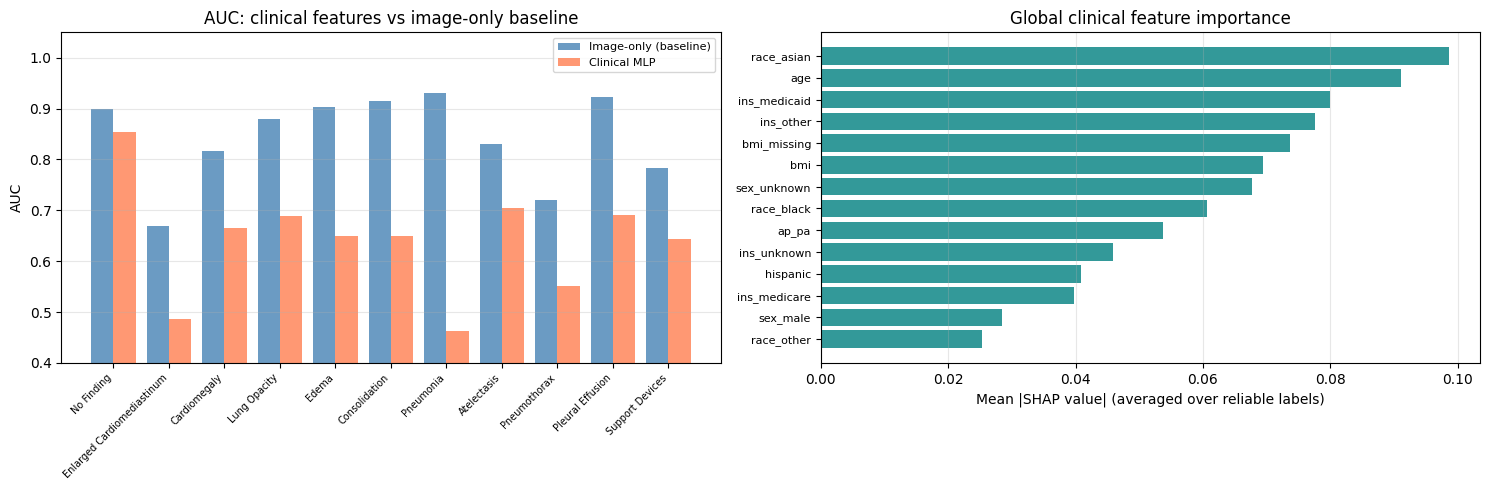

Saved: /Users/davidone/fac/diz/dizertatie_project/maps/shap/clinical_summary.png


In [13]:
# ── Cell 11 — Plots ───────────────────────────────────────────────────────────

reliable    = [l for l in LABEL_COLS if int(val_pos.get(l, 0)) >= RELIABLE_MIN]
rel_idx     = [LABEL_COLS.index(l) for l in reliable]
fig, axes   = plt.subplots(1, 2, figsize=(15, 5))

# Left: AUC per label — clinical vs image baseline
ax = axes[0]
x  = np.arange(len(reliable))
ax.bar(x - 0.2, [df_res.loc[l, 'image_only'] for l in reliable], 0.4,
       label='Image-only (baseline)', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, [df_res.loc[l, 'clinical']   for l in reliable], 0.4,
       label='Clinical MLP',          color='coral',     alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(reliable, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 1.05)
ax.set_title('AUC: clinical features vs image-only baseline')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Right: global SHAP feature importance (mean |SHAP| over reliable labels and val images)
ax         = axes[1]
global_imp = np.abs(shap_arr[rel_idx]).mean(axis=(0, 1))   # [n_features]
order      = np.argsort(global_imp)
ax.barh(range(N_FEATURES), global_imp[order], color='teal', alpha=0.8)
ax.set_yticks(range(N_FEATURES))
ax.set_yticklabels([FEATURE_NAMES[i] for i in order], fontsize=8)
ax.set_xlabel('Mean |SHAP value| (averaged over reliable labels)')
ax.set_title('Global clinical feature importance')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(MAPS_DIR / 'shap' / 'clinical_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {MAPS_DIR / "shap" / "clinical_summary.png"}')